RAG : 

5 components are important here : 

1. Document Loader : reads your raw files and converts them into doc objects. Determines what text actually enters the pipeline. 

2. Text Splitter - Critical : 
How you chunk your documents directly determines the retrieval quality 

Too large : unfocussed vectors : poor retrieval
Too small : loses context mid sentence : LLM gets incomplete information 
No overlap : boundary sentences lost between chunks / no contextual sharing

3. Embedding Model : Convert page_content of each chunk -> vector of floating point numbers.
text-embedding-3-small : 1536 dims for retrieval precision and for 3-large : 3072 dims

4. Vector Store : 
Store all the chunk vectors + their metadata + raw text.
Runs cosine similarity at the query time.

5. LLM : it does synthesis and not retrieval, it does not search , it reads the chunks you gave it 
and writes the answer.

Quality of output/answer = function(Retrieval quality)

# 🔍 RAG Deep Dive — GPT-1 Paper
**Paper:** *Improving Language Understanding by Generative Pre-Training* (Radford et al., OpenAI 2018)

**What we build:** A full RAG pipeline — load the GPT-1 PDF → chunk → embed → store in ChromaDB → retrieve with cosine scores → answer with GPT-4o

**What we deeply understand:**
- Document objects and what loaders actually do
- Why chunking exists and how overlap works
- What an embedding vector actually is (3072 floats)
- **Cosine similarity from scratch — math, intuition, visualization**
- How ChromaDB ranks chunks against a query
- How GPT-4o uses retrieved context to answer grounded questions

---

```
GPT-1 PDF
    │
    ▼
[PyPDFLoader]  →  List[Document]  (one per page, raw text)
    │
    ▼
[RecursiveCharacterTextSplitter]  →  List[Document]  (chunks, 800 chars each)
    │
    ▼
[text-embedding-3-large]  →  3072-dim vectors per chunk
    │
    ▼
[ChromaDB]  →  persisted vector store (vector + content + metadata)
    │
    ▼
[Retriever]  →  cosine similarity → ranked top-k chunks
    │
    ▼
[GPT-4o]  →  grounded answer from paper content
```

In [3]:
!pip install langchain langchain-community langchain-openai langchain-chroma langchain-text-splitters chromadb pypdf matplotlib scikit-learn numpy openai 

In [ ]:
import os 
os.environ["OPENAI_API_KEY"]=

In [5]:
# Document Loading
from langchain_community.document_loaders import PyPDFLoader

PDF_PATH="2018 (OpenAI) (Arxiv) [GPT-1] Improving Language Understanding by Generative Pre-Training.pdf"

loader = PyPDFLoader(PDF_PATH)

docs = loader.load()   # returns the list[doc objects]

print(f"Total pages loaded : {len(docs)}")
print(f"Page content with 500 chars...\n{docs[0].page_content[:500]}")
print(f"Metadata : {docs[0].metadata}")

Total pages loaded : 12
Page content with 500 chars...
Improving Language Understanding
by Generative Pre-Training
Alec Radford
OpenAI
alec@openai.com
Karthik Narasimhan
OpenAI
karthikn@openai.com
Tim Salimans
OpenAI
tim@openai.com
Ilya Sutskever
OpenAI
ilyasu@openai.com
Abstract
Natural language understanding comprises a wide range of diverse tasks such
as textual entailment, question answering, semantic similarity assessment, and
document classiﬁcation. Although large unlabeled text corpora are abundant,
labeled data for learning these speciﬁc tas
Metadata : {'producer': 'pdfTeX-1.40.18', 'creator': 'LaTeX with hyperref package', 'creationdate': '2018-06-08T19:14:34+00:00', 'author': '', 'keywords': '', 'moddate': '2018-06-08T19:14:34+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.18 (TeX Live 2017) kpathsea version 6.2.3', 'subject': '', 'title': '', 'trapped': '/False', 'source': '2018 (OpenAI) (Arxiv) [GPT-1] Improving Language Understanding by Generative 

In [6]:
# Inspect all 12 pages — char count and content preview
print(f"{'Page':<6} {'Chars':<10} {'Content Preview'}")
print("-" * 75)
for i, doc in enumerate(docs):
    preview = doc.page_content[:65].replace("\n", " ") # replace line break by space
    print(f"{i:<6} {len(doc.page_content):<10} {preview}...")

Page   Chars      Content Preview
---------------------------------------------------------------------------
0      3355       Improving Language Understanding by Generative Pre-Training Alec ...
1      4904       In this paper, we explore a semi-supervised approach for language...
2      3301       pre-trained language or machine translation model as auxiliary fe...
3      2894       Figure 1: (left) Transformer architecture and training objectives...
4      4171       Table 1: A list of the different tasks and datasets used in our e...
5      3349       Table 2: Experimental results on natural language inference tasks...
6      2275       Table 4: Semantic similarity and classiﬁcation results, comparing...
7      4267       Table 5: Analysis of various model ablations on different tasks. ...
8      3835       [2] J. L. Ba, J. R. Kiros, and G. E. Hinton. Layer normalization....
9      3487       [24] F. Jiao, S. Wang, C.-H. Lee, R. Greiner, and D. Schuurmans. ...
10     3936       [4

In [7]:
# Chunking - Text splitting 
# distinct sections - abstract, framework, etc
# if we embed entire page -> vectors are blurry average of everything on the page 
# loses specificity , we want smaller focussed chunks

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 800,
    chunk_overlap = 100
)

chunks = text_splitter.split_documents(docs)

print(f"Pages loaded : {len(docs)}")
print(f"From the document objects how many chunks created ? : {len(chunks)}")

Pages loaded : 12
From the document objects how many chunks created ? : 62


In [8]:
# Inspect first 4 chunks in detail — notice metadata is preserved from the loader
for i in range(4):
    print(f"\n── Chunk {i} {'─'*50}")
    print(f"  Metadata  : {chunks[i].metadata}")
    print(f"  Char len  : {len(chunks[i].page_content)}")
    print(f"  Content   :\n{chunks[i].page_content}")


── Chunk 0 ──────────────────────────────────────────────────
  Metadata  : {'producer': 'pdfTeX-1.40.18', 'creator': 'LaTeX with hyperref package', 'creationdate': '2018-06-08T19:14:34+00:00', 'author': '', 'keywords': '', 'moddate': '2018-06-08T19:14:34+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.18 (TeX Live 2017) kpathsea version 6.2.3', 'subject': '', 'title': '', 'trapped': '/False', 'source': '2018 (OpenAI) (Arxiv) [GPT-1] Improving Language Understanding by Generative Pre-Training.pdf', 'total_pages': 12, 'page': 0, 'page_label': '1'}
  Char len  : 788
  Content   :
Improving Language Understanding
by Generative Pre-Training
Alec Radford
OpenAI
alec@openai.com
Karthik Narasimhan
OpenAI
karthikn@openai.com
Tim Salimans
OpenAI
tim@openai.com
Ilya Sutskever
OpenAI
ilyasu@openai.com
Abstract
Natural language understanding comprises a wide range of diverse tasks such
as textual entailment, question answering, semantic similarity assessment, and
document 

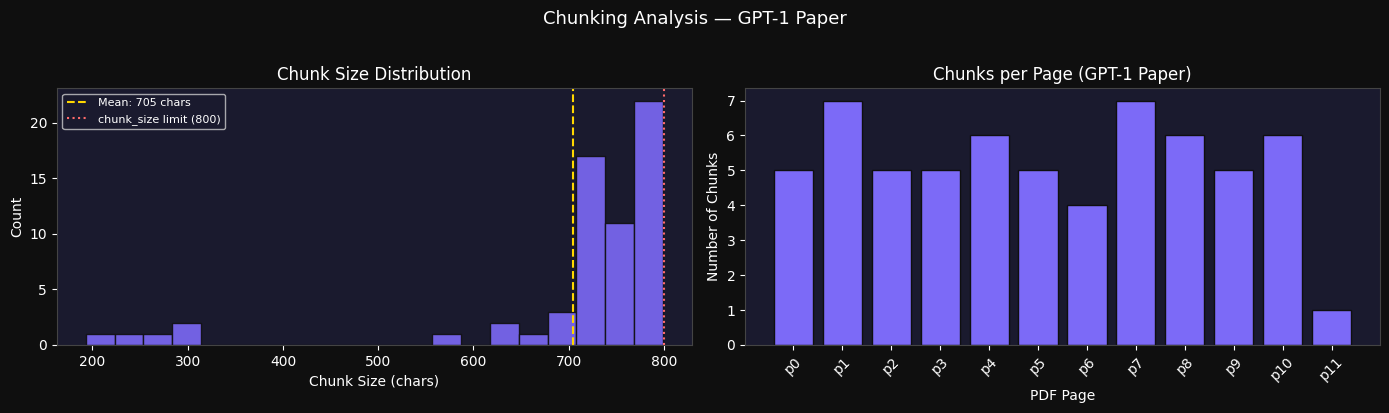

In [9]:
# Visualize chunk size distribution
import matplotlib.pyplot as plt
import numpy as np

chunk_sizes = [len(c.page_content) for c in chunks]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#0f0f0f')

for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

# Histogram
axes[0].hist(chunk_sizes, bins=20, color='#7c6af7', edgecolor='#0f0f0f', alpha=0.9)
axes[0].axvline(np.mean(chunk_sizes), color='#ffd700', linestyle='--',
                linewidth=1.5, label=f'Mean: {np.mean(chunk_sizes):.0f} chars')
axes[0].axvline(800, color='#ff6b6b', linestyle=':', linewidth=1.5, label='chunk_size limit (800)')
axes[0].set_xlabel('Chunk Size (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title('Chunk Size Distribution')
axes[0].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)

# Chunks per page
from collections import Counter
page_counts = Counter(c.metadata.get('page', 0) for c in chunks)
pages = sorted(page_counts.keys())
counts = [page_counts[p] for p in pages]
axes[1].bar([f"p{p}" for p in pages], counts, color='#7c6af7', edgecolor='#0f0f0f')
axes[1].set_xlabel('PDF Page')
axes[1].set_ylabel('Number of Chunks')
axes[1].set_title('Chunks per Page (GPT-1 Paper)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Chunking Analysis — GPT-1 Paper', color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
# STEP 3 — Embeddings: What are vectors?

An embedding converts text into a **list of floats** that encodes semantic meaning.

```
"GPT-1 uses a transformer decoder architecture"  →  [0.023, -0.011, 0.087, ...]  3072 floats
"The model applies multi-headed self-attention"  →  [0.019, -0.009, 0.091, ...]  3072 floats
"I enjoy cooking pasta on weekends"              →  [-0.12,  0.034, -0.050, ...]  3072 floats
```

The first two sentences are about the same concept → their vectors **point in nearly the same direction** in 3072-dimensional space.

The pasta sentence is unrelated → its vector **points in a very different direction**.

**This directional relationship is how retrieval works.** We find chunks whose vectors point in the same direction as the query vector.

In [10]:
from langchain_openai import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-large")

# Embed a single chunk — see what the vector looks like
sample_text   = chunks[0].page_content
sample_vector = embedding_model.embed_query(sample_text)

print(f"Input text (first 150 chars) : {sample_text[:150]}...")
print()
print(f"Vector type   : {type(sample_vector)}")
print(f"Vector length : {len(sample_vector)} dimensions")
print(f"First 10 dims : {[round(v, 6) for v in sample_vector[:10]]}")
print(f"Min value     : {min(sample_vector):.6f}")
print(f"Max value     : {max(sample_vector):.6f}")
print(f"Mean value    : {sum(sample_vector)/len(sample_vector):.6f}")

Input text (first 150 chars) : Improving Language Understanding
by Generative Pre-Training
Alec Radford
OpenAI
alec@openai.com
Karthik Narasimhan
OpenAI
karthikn@openai.com
Tim Sali...

Vector type   : <class 'list'>
Vector length : 3072 dimensions
First 10 dims : [0.021087, 0.011844, -0.011321, -0.028546, 0.000794, 0.033035, -0.027119, 0.024471, -0.025968, -0.018348]
Min value     : -0.081402
Max value     : 0.082599
Mean value    : 0.000186


---
##### STEP 4 — Deep Dive: Cosine Similarity

####### The Math

Cosine similarity measures the **angle** between two vectors — not their magnitude, just their direction.

```
cosine_similarity(A, B) = (A · B) / (||A|| × ||B||)

A · B   = dot product       = Σ(aᵢ × bᵢ)  for all i
||A||   = magnitude of A    = √(Σ aᵢ²)
||B||   = magnitude of B    = √(Σ bᵢ²)
```

##### Score Interpretation
```
1.0   → vectors point in exact same direction → semantically identical
0.8+  → very similar meaning
0.5   → somewhat related
0.0   → completely unrelated (perpendicular vectors)
-1.0  → opposite meaning (rare in practice)
```

ChromaDB uses cosine similarity internally to score and rank every chunk against your query.

In [11]:
import numpy as np

def cosine_similarity(vec_a: list, vec_b: list) -> float:
    """Manual cosine similarity implementation — no sklearn."""
    a = np.array(vec_a)
    b = np.array(vec_b)
    dot_product = np.dot(a, b)           # A · B
    magnitude_a = np.linalg.norm(a)      # ||A||
    magnitude_b = np.linalg.norm(b)      # ||B||
    return float(dot_product / (magnitude_a * magnitude_b))


# Three sentences — 2 from the paper domain, 1 completely unrelated
sent_a = "GPT-1 uses a transformer decoder with masked self-attention for language modeling."
sent_b = "The model applies multi-headed attention over input context tokens followed by feedforward layers."
sent_c = "I enjoy cooking pasta and watching movies on weekends."

print("Embedding 3 sentences...")
vec_a = embedding_model.embed_query(sent_a)
vec_b = embedding_model.embed_query(sent_b)
vec_c = embedding_model.embed_query(sent_c)

sim_ab = cosine_similarity(vec_a, vec_b)
sim_ac = cosine_similarity(vec_a, vec_c)
sim_bc = cosine_similarity(vec_b, vec_c)

print()
print(f"Sentence A : {sent_a}")
print(f"Sentence B : {sent_b}")
print(f"Sentence C : {sent_c}")
print()
print(f"Similarity A ↔ B  (both about GPT-1 architecture) : {sim_ab:.4f}  ← should be HIGH")
print(f"Similarity A ↔ C  (GPT-1 vs pasta)                : {sim_ac:.4f}  ← should be LOW")
print(f"Similarity B ↔ C  (attention vs pasta)             : {sim_bc:.4f}  ← should be LOW")

Embedding 3 sentences...

Sentence A : GPT-1 uses a transformer decoder with masked self-attention for language modeling.
Sentence B : The model applies multi-headed attention over input context tokens followed by feedforward layers.
Sentence C : I enjoy cooking pasta and watching movies on weekends.

Similarity A ↔ B  (both about GPT-1 architecture) : 0.5102  ← should be HIGH
Similarity A ↔ C  (GPT-1 vs pasta)                : 0.0126  ← should be LOW
Similarity B ↔ C  (attention vs pasta)             : 0.0381  ← should be LOW


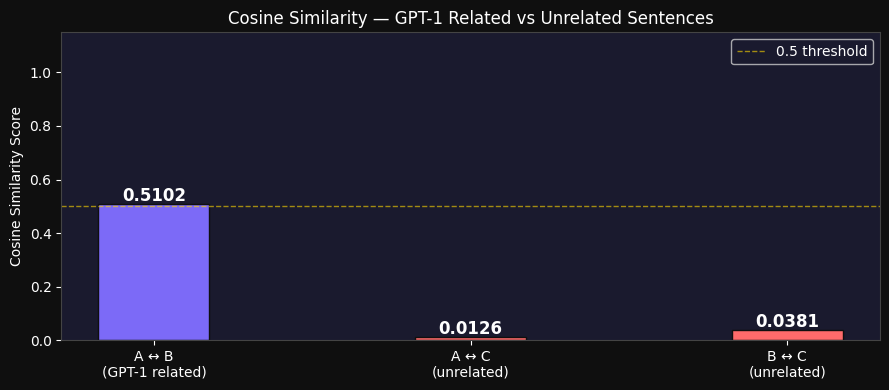

In [12]:
# Visualize similarity scores
pairs  = ["A ↔ B\n(GPT-1 related)", "A ↔ C\n(unrelated)", "B ↔ C\n(unrelated)"]
scores = [sim_ab, sim_ac, sim_bc]
colors = ['#7c6af7' if s > 0.5 else '#ff6b6b' for s in scores]

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

bars = ax.bar(pairs, scores, color=colors, edgecolor='#0f0f0f', width=0.35)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{score:.4f}", ha='center', color='white', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Cosine Similarity Score', color='white')
ax.set_title('Cosine Similarity — GPT-1 Related vs Unrelated Sentences', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.axhline(0.5, color='#ffd700', linestyle='--', linewidth=1, alpha=0.6, label='0.5 threshold')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.show()

Embedding first 10 chunks for heatmap...


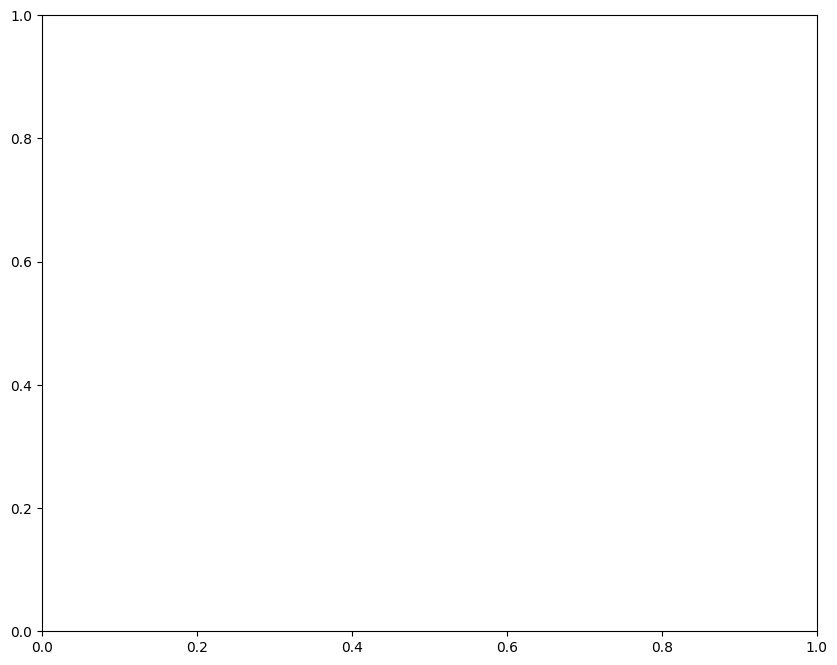

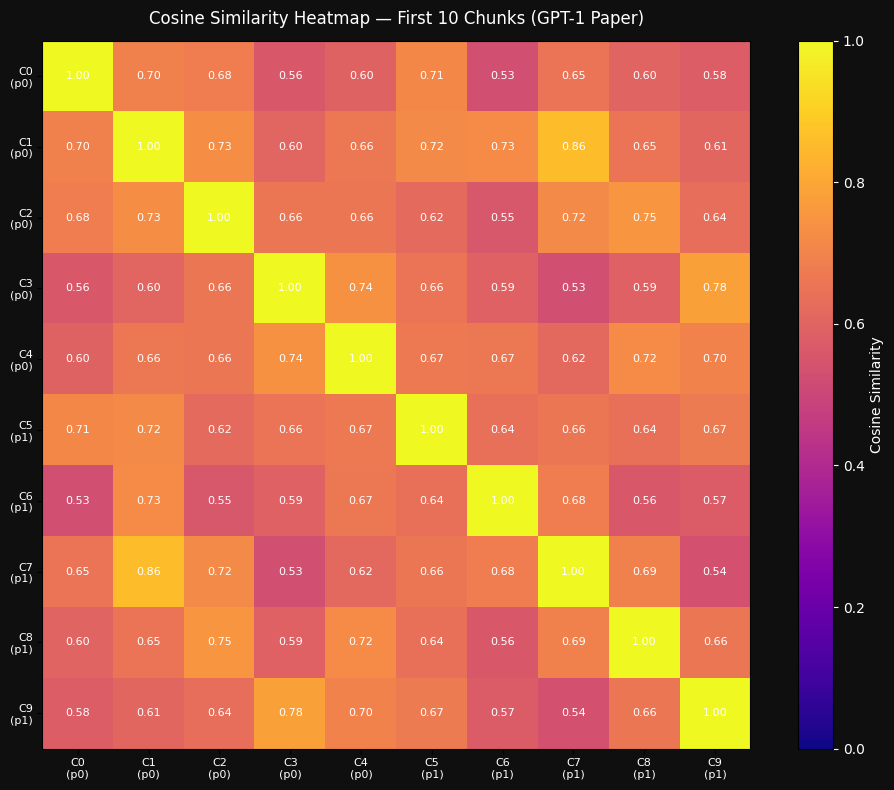


Observations:
  - Diagonal = 1.0 always (chunk vs itself)
  - Adjacent chunks share overlap text → slightly higher similarity
  - Chunks from same section (same page) tend to cluster with higher scores
  - Reference/bibliography chunks (pages 8-11) will diverge from body text


In [13]:
# ── Cosine Similarity Heatmap across first 10 chunks of the paper ─────────────
N = 10
sample_chunks = chunks[:N]

print(f"Embedding first {N} chunks for heatmap...")
vecs = [embedding_model.embed_query(c.page_content) for c in sample_chunks]

# Build NxN similarity matrix
sim_matrix = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        sim_matrix[i][j] = cosine_similarity(vecs[i], vecs[j])

# Labels: chunk index + page
labels = [f"C{i}\n(p{sample_chunks[i].metadata.get('page','?')})" for i in range(N)]

fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

im = ax.imshow(sim_matrix, cmap='plasma', vmin=0, vmax=1)
cbar = plt.colorbar(im, ax=ax, label='Cosine Similarity')
cbar.ax.yaxis.label.set_color('white')
cbar.ax.tick_params(colors='white')

ax.set_xticks(range(N)); ax.set_xticklabels(labels, color='white', fontsize=8)
ax.set_yticks(range(N)); ax.set_yticklabels(labels, color='white', fontsize=8)
ax.set_title('Cosine Similarity Heatmap — First 10 Chunks (GPT-1 Paper)',
             color='white', fontsize=12, pad=12)

for i in range(N):
    for j in range(N):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}",
                ha='center', va='center', color='white', fontsize=8)

plt.tight_layout()
plt.show()

print()
print("Observations:")
print("  - Diagonal = 1.0 always (chunk vs itself)")
print("  - Adjacent chunks share overlap text → slightly higher similarity")
print("  - Chunks from same section (same page) tend to cluster with higher scores")
print("  - Reference/bibliography chunks (pages 8-11) will diverge from body text")

In [14]:
# store the vectors in chroma DB 

from langchain_chroma import Chroma

print(f"Embedding {len(chunks)} chunks and storing in ChromaDB...")
print(f"Model: text-embedding-3-large → 3072 dims per chunk")
print(f"Total API calls to OpenAI: {len(chunks)}")
print()

vectorstore = Chroma.from_documents(
    documents         = chunks,
    embedding         = embedding_model,
    persist_directory = "./chroma_gpt1",
    collection_name   = "gpt1_paper"
)

total = vectorstore._collection.count()
print(f"✅ {total} vectors stored in ChromaDB at ./chroma_gpt1")

Embedding 62 chunks and storing in ChromaDB...
Model: text-embedding-3-large → 3072 dims per chunk
Total API calls to OpenAI: 62

✅ 124 vectors stored in ChromaDB at ./chroma_gpt1


In [15]:
# ── Peek inside ChromaDB — what's actually stored ─────────────────────────────
collection_data = vectorstore._collection.get(
    include=["embeddings", "documents", "metadatas"]
)

ids        = collection_data["ids"]
embeddings = collection_data["embeddings"]
documents  = collection_data["documents"]
metadatas  = collection_data["metadatas"]

print(f"Total stored  : {len(ids)}")
print(f"Vector dims   : {len(embeddings[0])}  ← confirms text-embedding-3-large")
print()

for i in range(5):
    print(f"Chunk {i} | ID: {ids[i]}")
    print(f"  Meta    : {metadatas[i]}")
    print(f"  Content : {documents[i][:100]}...")
    print(f"  Vector  : {[round(v,5) for v in embeddings[i][:5]]} ... ({len(embeddings[i])} dims)")
    print()

Total stored  : 124
Vector dims   : 3072  ← confirms text-embedding-3-large

Chunk 0 | ID: 4d5250c4-83da-4674-aa0e-b613dac9b0e5
  Meta    : {'title': '', 'trapped': '/False', 'author': '', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.18 (TeX Live 2017) kpathsea version 6.2.3', 'subject': '', 'page': 0, 'total_pages': 12, 'page_label': '1', 'producer': 'pdfTeX-1.40.18', 'moddate': '2018-06-08T19:14:34+00:00', 'creator': 'LaTeX with hyperref package', 'source': '2018 (OpenAI) (Arxiv) [GPT-1] Improving Language Understanding by Generative Pre-Training.pdf', 'creationdate': '2018-06-08T19:14:34+00:00', 'keywords': ''}
  Content : Improving Language Understanding
by Generative Pre-Training
Alec Radford
OpenAI
alec@openai.com
Kart...
  Vector  : [0.02107, 0.01185, -0.01132, -0.0286, 0.0008] ... (3072 dims)

Chunk 1 | ID: 37b73c0f-efff-4ed9-9718-59793100629a
  Meta    : {'total_pages': 12, 'source': '2018 (OpenAI) (Arxiv) [GPT-1] Improving Language Understanding by Generati

In [16]:
# retrieval with cosine similarity from chroma DB

def retrieve_with_scores(query: str, k: int = 5):
    """Retrieve top-k chunks with cosine similarity scores."""
    results = vectorstore.similarity_search_with_relevance_scores(query, k=k)
    print(f"Query : '{query}'")
    print(f"Top {k} results:\n")
    for i, (doc, score) in enumerate(results):
        print(f"  Rank {i+1} | Score: {score:.4f} | Page: {doc.metadata.get('page','?')}")
        print(f"  {doc.page_content[:180]}...")
        print()
    return results

# Test with a question grounded in the paper
results = retrieve_with_scores("What two-stage training procedure does GPT-1 use?")

Query : 'What two-stage training procedure does GPT-1 use?'
Top 5 results:

  Rank 1 | Score: 0.3182 | Page: 2
  objective to their target task objective and demonstrated performance gains on sequence labeling
tasks. Our experiments also use an auxiliary objective, but as we show, unsupervise...

  Rank 2 | Score: 0.3182 | Page: 2
  objective to their target task objective and demonstrated performance gains on sequence labeling
tasks. Our experiments also use an auxiliary objective, but as we show, unsupervise...

  Rank 3 | Score: 0.2909 | Page: 4
  12-layer decoder-only transformer with masked self-attention heads (768 dimensional states and 12
attention heads). For the position-wise feed-forward networks, we used 3072 dimens...

  Rank 4 | Score: 0.2908 | Page: 4
  12-layer decoder-only transformer with masked self-attention heads (768 dimensional states and 12
attention heads). For the position-wise feed-forward networks, we used 3072 dimens...

  Rank 5 | Score: 0.2829 | Page: 1
 

In [17]:
# Test with more paper-specific questions
queries = [
    "What dataset was used for unsupervised pre-training?",
    "What model architecture does GPT-1 use and why was it chosen?",
    "What were the ablation study results?",
]

for q in queries:
    print("=" * 65)
    retrieve_with_scores(q, k=3)

Query : 'What dataset was used for unsupervised pre-training?'
Top 3 results:

  Rank 1 | Score: 0.3777 | Page: 1
  Unsupervised pre-training Unsupervised pre-training is a special case of semi-supervised learning
where the goal is to ﬁnd a good initialization point instead of modifying the supe...

  Rank 2 | Score: 0.3777 | Page: 1
  Unsupervised pre-training Unsupervised pre-training is a special case of semi-supervised learning
where the goal is to ﬁnd a good initialization point instead of modifying the supe...

  Rank 3 | Score: 0.3348 | Page: 1
  In this paper, we explore a semi-supervised approach for language understanding tasks using a
combination of unsupervised pre-training and supervised ﬁne-tuning. Our goal is to lea...

Query : 'What model architecture does GPT-1 use and why was it chosen?'
Top 3 results:

  Rank 1 | Score: 0.2362 | Page: 4
  12-layer decoder-only transformer with masked self-attention heads (768 dimensional states and 12
attention heads). For the positi

In [18]:
# RAG 

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

llm       = ChatOpenAI(model="gpt-4o", temperature=0)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

def rag_answer(query: str, show_sources: bool = True) -> str:
    """Full RAG pipeline — retrieve chunks from GPT-1 paper → generate answer with GPT-4o."""

    # Step 1 — retrieve relevant chunks from ChromaDB
    retrieved = retriever.invoke(query)

    # Step 2 — build context string with page references
    context = "\n\n".join(
        f"[Page {doc.metadata.get('page', '?')}]\n{doc.page_content}"
        for doc in retrieved
    )

    # Step 3 — construct prompt
    messages = [
        SystemMessage(content=(
            "You are a precise research paper assistant. "
            "Answer the question using ONLY the provided context from the GPT-1 paper. "
            "If the answer is not in the context, say: 'This is not covered in the retrieved sections.' "
            "Be specific, cite page numbers where possible, and do not hallucinate."
        )),
        HumanMessage(content=f"Context from GPT-1 paper:\n{context}\n\nQuestion: {query}")
    ]

    # Step 4 — call GPT-4o
    response = llm.invoke(messages)

    if show_sources:
        print("── Sources retrieved ──────────────────────────────────")
        for i, doc in enumerate(retrieved):
            print(f"  [{i+1}] Page {doc.metadata.get('page','?')} — {doc.page_content[:90]}...")
        print("───────────────────────────────────────────────────────")
        print()

    return response.content

In [19]:
# ── Question 1 ────────────────────────────────────────────────────────────────
q = "What two-stage training procedure does GPT-1 use?"
print(f"Q: {q}\n")
print(rag_answer(q))

Q: What two-stage training procedure does GPT-1 use?

── Sources retrieved ──────────────────────────────────
  [1] Page 2 — objective to their target task objective and demonstrated performance gains on sequence la...
  [2] Page 2 — objective to their target task objective and demonstrated performance gains on sequence la...
  [3] Page 4 — 12-layer decoder-only transformer with masked self-attention heads (768 dimensional states...
  [4] Page 4 — 12-layer decoder-only transformer with masked self-attention heads (768 dimensional states...
  [5] Page 1 — In this paper, we explore a semi-supervised approach for language understanding tasks usin...
───────────────────────────────────────────────────────

The GPT-1 model uses a two-stage training procedure consisting of:

1. **Unsupervised Pre-training**: In this stage, a high-capacity language model is learned on a large corpus of text using a standard language modeling objective. The goal is to maximize the likelihood of the sequence of

In [20]:
# ── Question 2 ────────────────────────────────────────────────────────────────
q = "What dataset was used for unsupervised pre-training and why was it chosen?"
print(f"Q: {q}\n")
print(rag_answer(q))

Q: What dataset was used for unsupervised pre-training and why was it chosen?

── Sources retrieved ──────────────────────────────────
  [1] Page 1 — Unsupervised pre-training Unsupervised pre-training is a special case of semi-supervised l...
  [2] Page 1 — Unsupervised pre-training Unsupervised pre-training is a special case of semi-supervised l...
  [3] Page 1 — In this paper, we explore a semi-supervised approach for language understanding tasks usin...
  [4] Page 1 — In this paper, we explore a semi-supervised approach for language understanding tasks usin...
  [5] Page 3 — generative model to learn to condition on long-range information. An alternative dataset, ...
───────────────────────────────────────────────────────

This is not covered in the retrieved sections.


In [21]:
# ── Question 3 ────────────────────────────────────────────────────────────────
q = "What model architecture does GPT-1 use and why was the Transformer chosen over LSTMs?"
print(f"Q: {q}\n")
print(rag_answer(q))

Q: What model architecture does GPT-1 use and why was the Transformer chosen over LSTMs?

── Sources retrieved ──────────────────────────────────
  [1] Page 1 — The closest line of work to ours involves pre-training a neural network using a language m...
  [2] Page 1 — The closest line of work to ours involves pre-training a neural network using a language m...
  [3] Page 1 — these parameters to a target task using the corresponding supervised objective.
For our mo...
  [4] Page 1 — these parameters to a target task using the corresponding supervised objective.
For our mo...
  [5] Page 4 — Table 1: A list of the different tasks and datasets used in our experiments.
Task Datasets...
───────────────────────────────────────────────────────

GPT-1 uses the Transformer model architecture. The Transformer was chosen over LSTMs because it allows for capturing longer-range linguistic structures, which is a limitation of LSTMs due to their restricted prediction ability to a short range. The Tra

In [22]:
# ── Question 4 ────────────────────────────────────────────────────────────────
q = "How does GPT-1 handle different task types during fine-tuning?"
print(f"Q: {q}\n")
print(rag_answer(q))

Q: How does GPT-1 handle different task types during fine-tuning?

── Sources retrieved ──────────────────────────────────
  [1] Page 3 — Figure 1: (left) Transformer architecture and training objectives used in this work. (righ...
  [2] Page 3 — Figure 1: (left) Transformer architecture and training objectives used in this work. (righ...
  [3] Page 4 — of 6.25e-5 and a batchsize of 32. Our model ﬁnetunes quickly and 3 epochs of training was ...
  [4] Page 4 — of 6.25e-5 and a batchsize of 32. Our model ﬁnetunes quickly and 3 epochs of training was ...
  [5] Page 0 — on a diverse corpus of unlabeled text, followed bydiscriminative ﬁne-tuning on each
speciﬁ...
───────────────────────────────────────────────────────

GPT-1 handles different task types during fine-tuning by using task-specific input transformations. For tasks like text classification, the model can be directly fine-tuned. However, for tasks with structured inputs, such as question answering or textual entailment, which in